In [3]:
from qiskit import QuantumCircuit
import numpy as np

def generate_1d_tfim_circuit(num_qubits, num_trotter_steps, rx_angle, rzz_angle, trotter_barriers=False, layer_barriers=False):
    """
    Generates a 1D Transverse Field Ising Model (TFIM) circuit using clean Qiskit primitives.
    """
    qc = QuantumCircuit(num_qubits)

    for trotter_step in range(num_trotter_steps):
        # 1. Even bonds Rzz
        for i in range(0, num_qubits - 1, 2):
            qc.rzz(rzz_angle, i, i + 1)
        if layer_barriers:
            qc.barrier()
            
        # 2. Odd bonds Rzz
        for i in range(1, num_qubits - 1, 2):
            qc.rzz(rzz_angle, i, i + 1)
        if layer_barriers:
            qc.barrier()
            
        # 3. Transverse field transverse driving (Rx)
        qc.rx(rx_angle, range(num_qubits))
        
        if trotter_barriers:
            qc.barrier()
            
    return qc

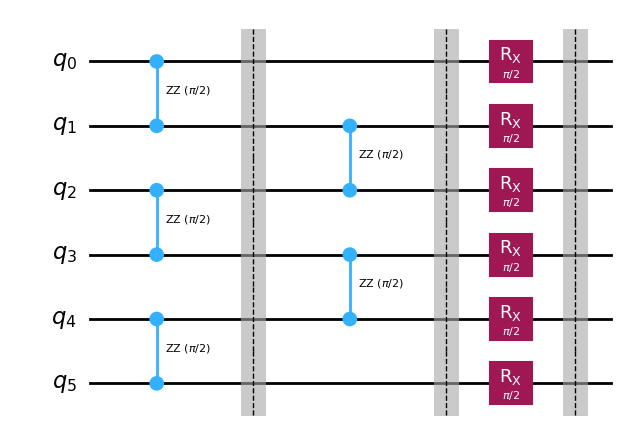

In [5]:
import numpy as np
from qiskit import QuantumCircuit


# 1. Redefine with a default value for rzz_angle (e.g., np.pi/2 or whatever your model uses)
def generate_1d_tfim_circuit(
    num_qubits,
    num_trotter_steps,
    rx_angle,
    rzz_angle=np.pi / 2,
    num_cl_bits=0,
    trotter_barriers=False,
    layer_barriers=False,
):
    if num_cl_bits == 0:
        qc = QuantumCircuit(num_qubits)
    else:
        qc = QuantumCircuit(num_qubits, num_cl_bits)

    for trotter_step in range(num_trotter_steps):
        # Even bonds Rzz
        for i in range(0, qc.num_qubits - 1, 2):
            qc.rzz(rzz_angle, i, i + 1)
        if layer_barriers:
            qc.barrier()

        # Odd bonds Rzz
        for i in range(1, qc.num_qubits - 1, 2):
            qc.rzz(rzz_angle, i, i + 1)
        if layer_barriers:
            qc.barrier()

        # Transverse field (Rx)
        qc.rx(rx_angle, list(range(qc.num_qubits)))

        if trotter_barriers:
            qc.barrier()

    return qc


# 2. Your execution cell will now evaluate perfectly without changing your arguments:
num_qubits = 6
num_trotter_steps = 1
rx_angle = 0.5 * np.pi

qc = generate_1d_tfim_circuit(
    num_qubits, num_trotter_steps, rx_angle, trotter_barriers=True, layer_barriers=True
)
qc.draw(output="mpl", fold=-1)